TensorFlow Version: 2.20.0

Dataset loaded from: /root/.keras/datasets/fra.txt
Total samples: 5000


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 256) │    323,072 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, None, 256) │    869,120 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, None,     │    525,312 │ embedding[0][0]   │
│                     │ 256), (None,      │            │                   │
│                     │ 256), (None,      │            │                   │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, None,     │    525,312 │ embedding_1[0][0… │
│                     │ 256), (None,      │            │ lstm[0][1],       │
│                     │ 256), (None,      │            │ lstm[0][2]        │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer     │ (None, None, 256) │          0 │ lstm_1[0][0],     │
│ (Attention)         │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, None, 512) │          0 │ lstm_1[0][0],     │
│ (Concatenate)       │                   │            │ attention_layer[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, None,      │  1,741,635 │ concatenate[0][0] │
│                     │ 3395)             │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,984,451 (15.20 MB)

 Trainable params: 3,984,451 (15.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.6461 - loss: 3.1564 - val_accuracy: 0.6481 - val_loss: 2.3405
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.7351 - loss: 1.8281 - val_accuracy: 0.6884 - val_loss: 2.1859
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.7467 - loss: 1.6239 - val_accuracy: 0.6899 - val_loss: 2.0758
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.7564 - loss: 1.4876 - val_accuracy: 0.7067 - val_loss: 2.0196
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - accuracy: 0.7686 - loss: 1.3786 - val_accuracy: 0.7200 - val_loss: 1.9727

Generating Attention Heatmap...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step


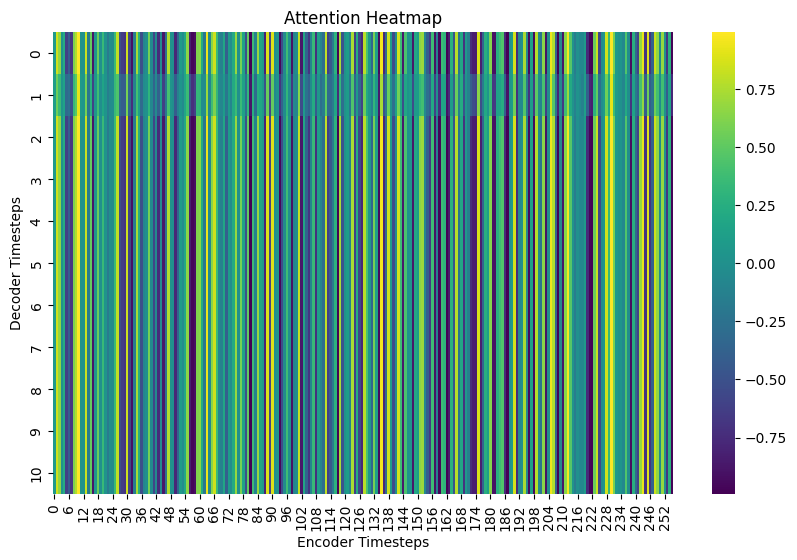


Lab 6 Completed Successfully ✅


In [ ]:
# ==========================================
# LAB 6: SEQ2SEQ + ATTENTION HEATMAP (FINAL)
# ==========================================

import tensorflow as tf
import numpy as np
import os
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, Attention, Concatenate
from tensorflow.keras.models import Model

print("TensorFlow Version:", tf.__version__)

# ==========================================
# STEP 1: DOWNLOAD + FIX DATASET
# ==========================================

print("\nDownloading dataset...")

zip_path = tf.keras.utils.get_file(
    fname="fra-eng.zip",
    origin="http://storage.googleapis.com/download.tensorflow.org/data/fra-eng.zip"
)

# Force extract
extract_dir = os.path.dirname(zip_path)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Find fra.txt automatically
data_path = None
for root, dirs, files in os.walk(extract_dir):
    if "fra.txt" in files:
        data_path = os.path.join(root, "fra.txt")
        break

if data_path is None:
    raise FileNotFoundError("fra.txt not found!")

print("Dataset loaded from:", data_path)

# ==========================================
# STEP 2: LOAD DATA
# ==========================================

lines = open(data_path, encoding="utf-8").read().split("\n")

input_texts = []
target_texts = []

for line in lines[:5000]:   # reduce if slow
    if "\t" not in line:
        continue

    parts = line.split("\t")

    if len(parts) < 2:
        continue

    eng = parts[0]
    fra = parts[1]

    input_texts.append(eng)
    target_texts.append("\t " + fra + " \n")

print("Total samples:", len(input_texts))

# ==========================================
# STEP 3: TOKENIZATION
# ==========================================

input_tokenizer = Tokenizer()
input_tokenizer.fit_on_texts(input_texts)

input_seq = input_tokenizer.texts_to_sequences(input_texts)
max_len_enc = max(len(s) for s in input_seq)
input_seq = pad_sequences(input_seq, maxlen=max_len_enc, padding="post")

target_tokenizer = Tokenizer(filters="")
target_tokenizer.fit_on_texts(target_texts)

target_seq = target_tokenizer.texts_to_sequences(target_texts)
max_len_dec = max(len(s) for s in target_seq)
target_seq = pad_sequences(target_seq, maxlen=max_len_dec, padding="post")

num_enc = len(input_tokenizer.word_index) + 1
num_dec = len(target_tokenizer.word_index) + 1

# Prepare decoder data
decoder_input = target_seq[:, :-1]
decoder_target = target_seq[:, 1:]

decoder_target = tf.keras.utils.to_categorical(
    decoder_target, num_classes=num_dec
)

# ==========================================
# STEP 4: BUILD MODEL WITH ATTENTION
# ==========================================

latent_dim = 256

# Encoder
encoder_inputs = Input(shape=(None,))
enc_emb = Embedding(num_enc, latent_dim)(encoder_inputs)

encoder_outputs, state_h, state_c = LSTM(
    latent_dim, return_sequences=True, return_state=True
)(enc_emb)

# Decoder
decoder_inputs = Input(shape=(None,))
dec_emb = Embedding(num_dec, latent_dim)(decoder_inputs)

decoder_outputs, _, _ = LSTM(
    latent_dim, return_sequences=True, return_state=True
)(dec_emb, initial_state=[state_h, state_c])

# Attention
attention_layer = Attention(name="attention_layer")
attention_output = attention_layer([decoder_outputs, encoder_outputs])

# Combine
concat = Concatenate(axis=-1)([decoder_outputs, attention_output])

# Output
decoder_dense = Dense(num_dec, activation="softmax")
outputs = decoder_dense(concat)

# Model
model = Model([encoder_inputs, decoder_inputs], outputs)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ==========================================
# STEP 5: TRAIN
# ==========================================

model.fit(
    [input_seq, decoder_input],
    decoder_target,
    batch_size=64,
    epochs=5,
    validation_split=0.2
)

# ==========================================
# STEP 6: ATTENTION HEATMAP
# ==========================================

print("\nGenerating Attention Heatmap...")

# Extract attention output
attention_model = Model(
    inputs=model.input,
    outputs=model.get_layer("attention_layer").output
)

sample_input = input_seq[0:1]
sample_decoder = decoder_input[0:1]

attention_weights = attention_model.predict([sample_input, sample_decoder])

attention_matrix = attention_weights[0]

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(attention_matrix, cmap="viridis")

plt.title("Attention Heatmap")
plt.xlabel("Encoder Timesteps")
plt.ylabel("Decoder Timesteps")

plt.show()

print("\nLab 6 Completed Successfully ✅")